# Customer Booking Classification

## Data preparation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../data/customer_booking.csv',encoding='ISO-8859-1')

In [3]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 7.0 MB


In [5]:
labels = df['booking_complete']
df = df.drop(columns=['booking_complete'])

## EDA

In [6]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000


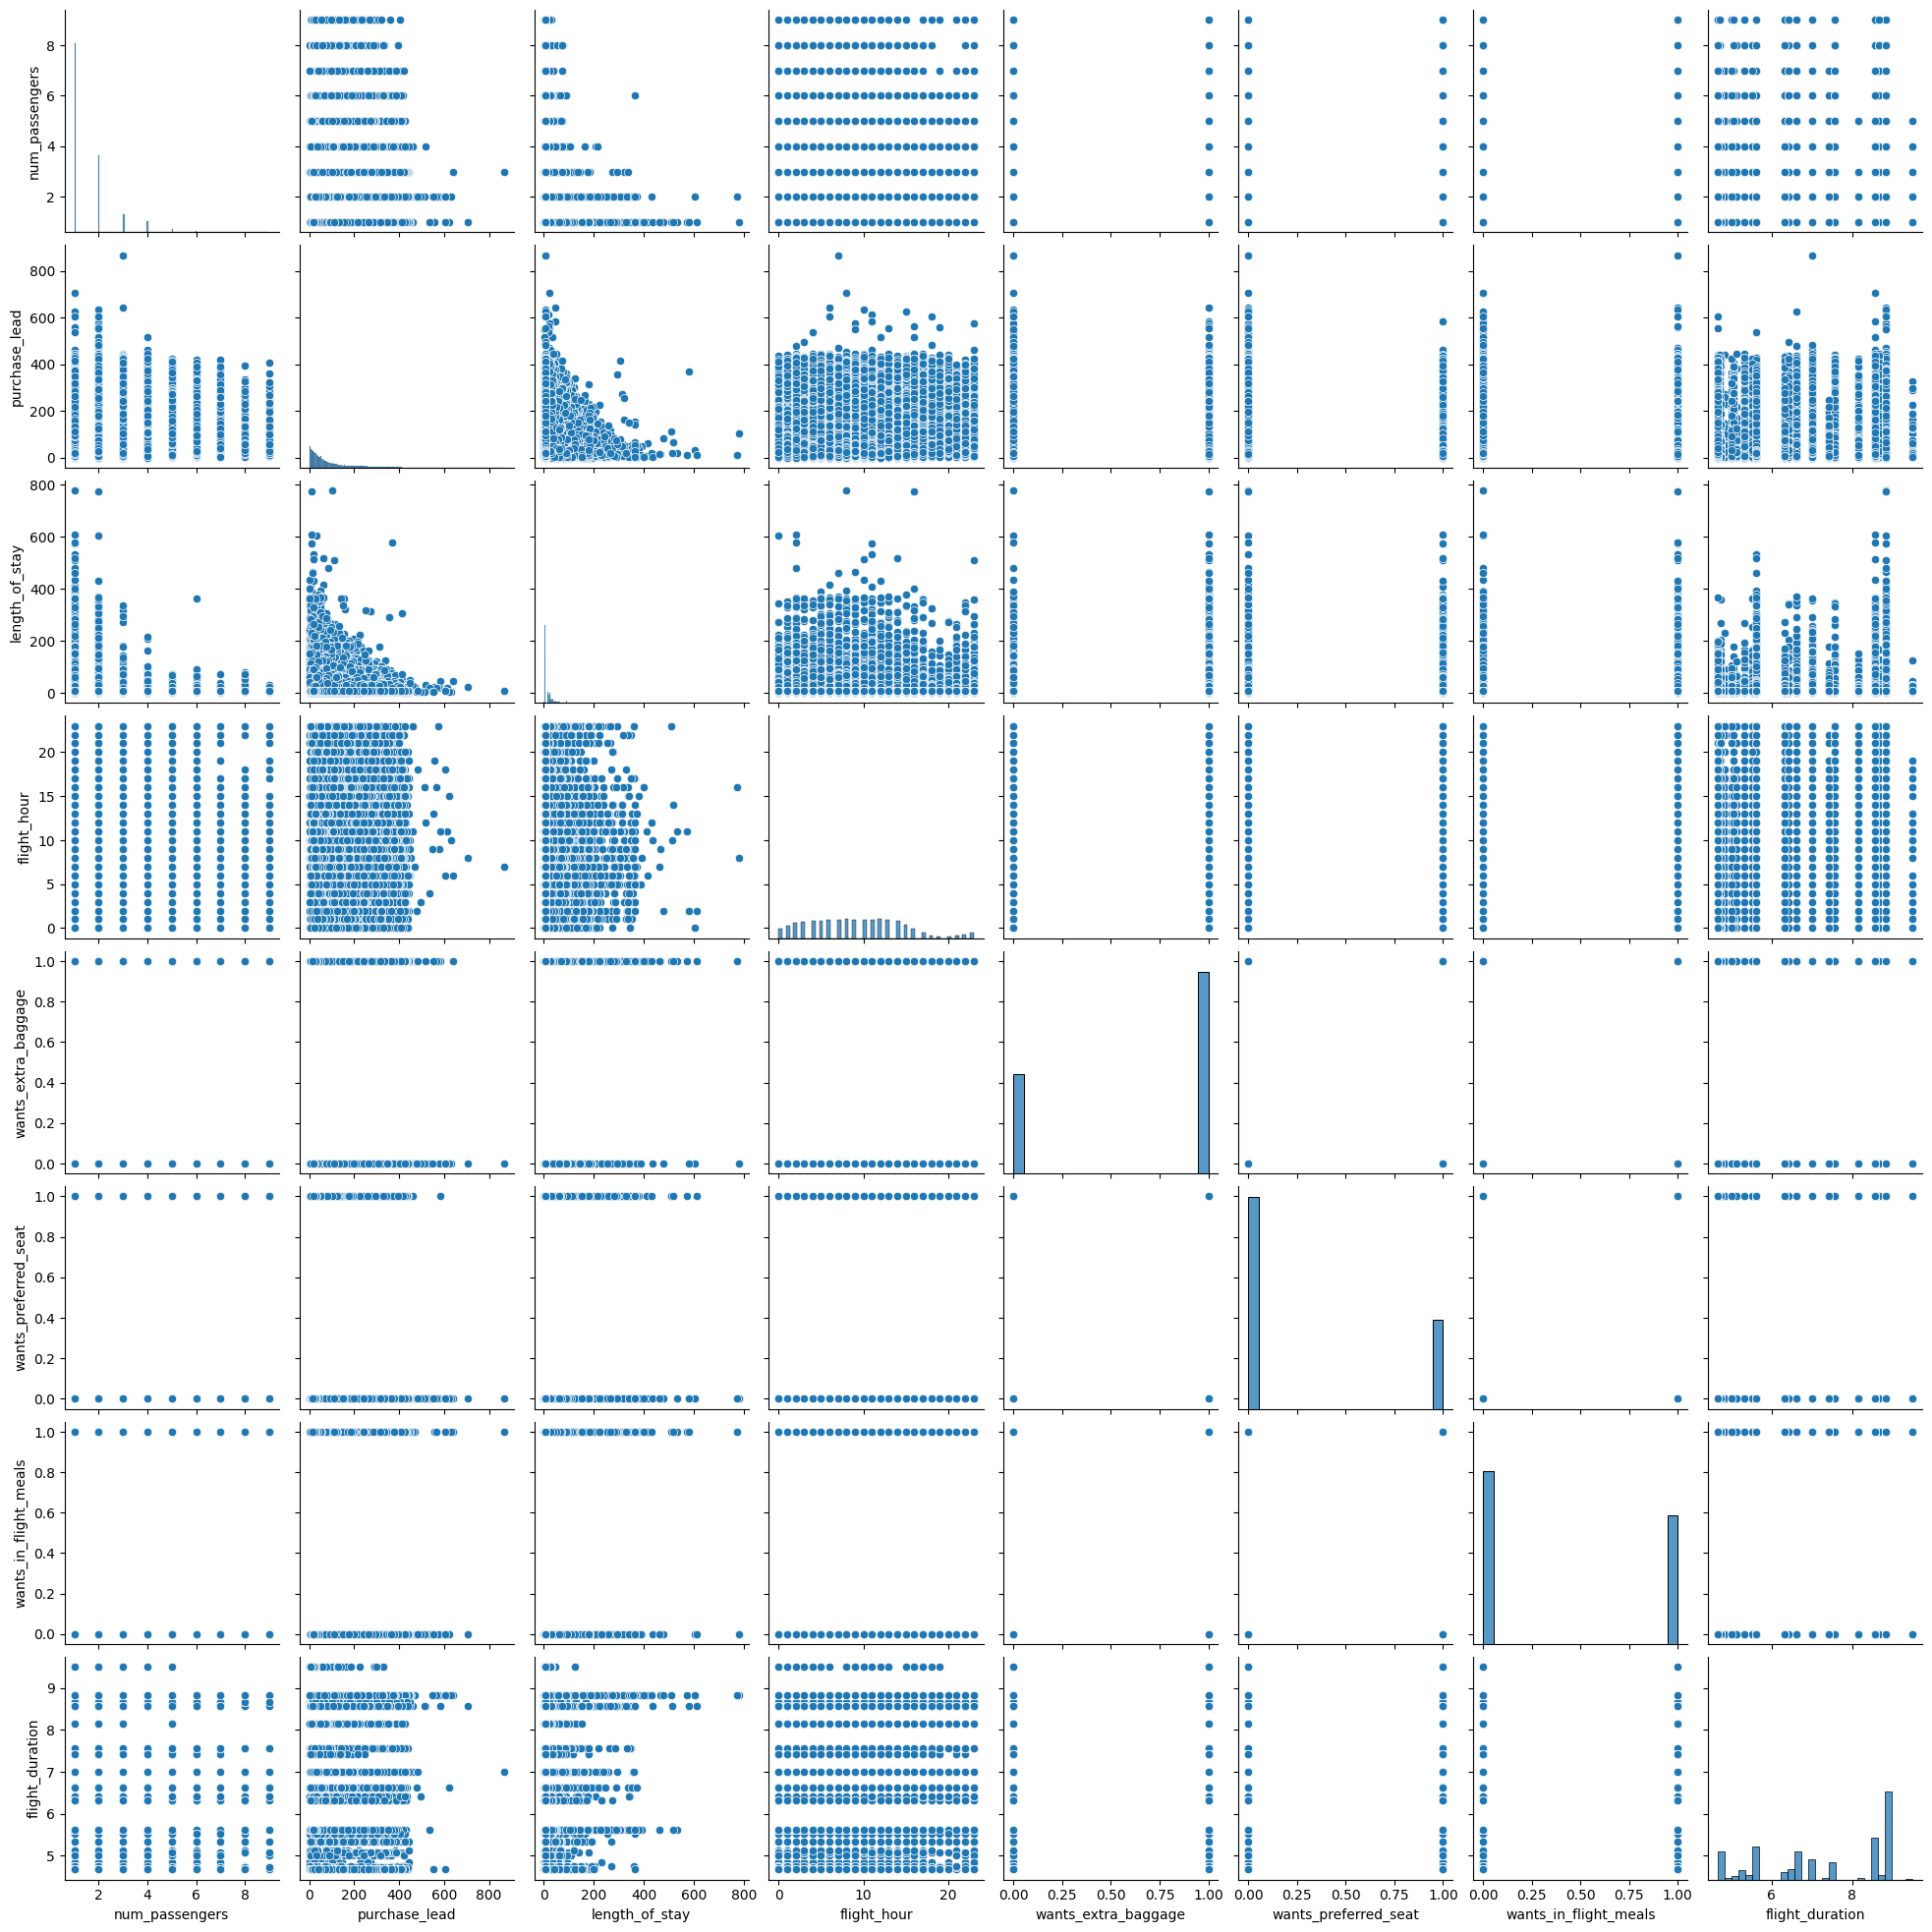

In [7]:
sns.pairplot(df.select_dtypes('number'))
plt.show()

In [8]:
df.select_dtypes('number').corr()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
num_passengers,1.000000,0.212606,-0.115850,0.015607,0.120404,0.028544,0.022943,-0.063169
purchase_lead,0.212606,1.000000,-0.076560,0.035973,-0.022207,-0.004499,-0.022653,0.067866
length_of_stay,-0.115850,-0.076560,1.000000,-0.024872,0.176757,0.032264,0.098828,0.141181
flight_hour,0.015607,0.035973,-0.024872,1.000000,-0.011434,0.012171,0.013014,-0.002101
wants_extra_baggage,0.120404,-0.022207,0.176757,-0.011434,1.000000,0.207669,0.216470,0.057054
wants_preferred_seat,0.028544,-0.004499,0.032264,0.012171,0.207669,1.000000,0.315088,0.101289
wants_in_flight_meals,0.022943,-0.022653,0.098828,0.013014,0.216470,0.315088,1.000000,0.154312
flight_duration,-0.063169,0.067866,0.141181,-0.002101,0.057054,0.101289,0.154312,1.000000


From the pair plot and the correlation coeffecients between the features, It seems there is no clear relationship between the numeric features.. wants_preferred_seat and wants_in_flight_meals have slight positive correlation between them with 0.31 correlatin coefficient.

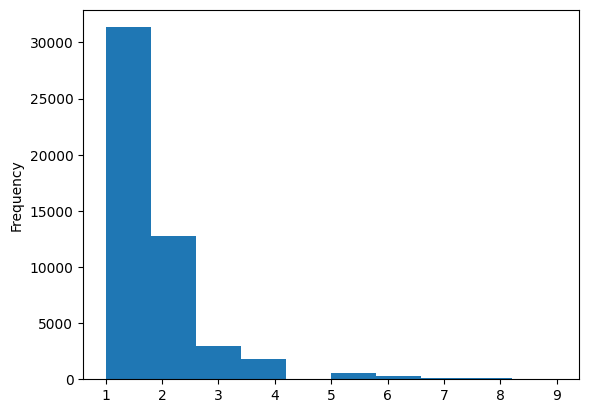

In [9]:
df['num_passengers'].plot(kind='hist')
plt.show()


In [10]:
labels.value_counts(normalize=True)

booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64

### Feature Engineering

In [11]:
df_test = df.copy(deep=True)

In [12]:
def create_base_features(df):
    #Map flight day in text to number in day of week
    days_mapping = {
        'Mon':1,
        'Tue':2,
        'Wed':3,
        'Thu':4,
        'Fri':5,
        'Sat':6,
        'Sun':7
    }
    df['flight_day'] = df['flight_day'].map(days_mapping)

    # Type of the stays (short, vacation, etc)
    stay_condition = [df['length_of_stay'] <= 15,df['length_of_stay'] <= 60, df['length_of_stay'] <= 180]
    df['stay_type'] = np.select(stay_condition,['short','vacation','temporary_residence'],default='residence')

    # Passenger grouping based on number of passengers
    passenger_condition = [df['num_passengers'] > 2,df['num_passengers'] == 2]
    df['passenger_kind'] = np.select(passenger_condition,['group','pair'],default='solo') 

    # 1. Traveling in am or pm  from flight_hour
    # 2. Whether travelling weekend or weekday from flight_day
    df['travel_am_pm'] = np.where(df['flight_hour']<12,'am','pm')
    df['weekend'] = np.where(df['flight_day'] <=5,0,1) 

    # Long or Short travel from fliht duration
    df['travelling_kind'] = np.where(df['flight_duration'] <=4.5,'short','long')

    # Split route into Departure and arrival features
    df[['departure','arrival']] = df['route'].str.extract(r'(.{3})(.{3})')
    df.drop(columns=['route'],inplace=True)

    # Category of leads from teh purchase_lead
    lead_condition = [
        df['purchase_lead'] <= 7,
        df['purchase_lead'] <= 30,
        df['purchase_lead'] <= 90
    ]
    df['lead_category'] = np.select(lead_condition,['last_minute','short_lead','medium_lead'],default='long_lead')

    # Period of travel (morning afternoon,etc)
    flight_period_condition = [
        df['flight_hour'] <6,
        df['flight_hour'] <12,
        df['flight_hour'] <18
    ]
    df['flight_period'] = np.select(flight_period_condition,['early_morning','morning','afternoon'],default='evening')
    return df



#### Interaction Features

In [13]:
def create_interaction_features(df):
    #Interaction features

    # Passengers taking extra services (ordinal)
    df['extra_services_count'] = df[['wants_extra_baggage','wants_preferred_seat','wants_in_flight_meals']].sum(axis=1)

    # Passengers booking and travel behavior
    booking_conditions = [
        (df['purchase_lead'] < 7) & (df['stay_type'] == 'short'),
        (df['purchase_lead'] >= 7) & (df['stay_type'] == 'short'),
        (df['purchase_lead'] < 7) & (df['stay_type'].isin(['vacation','temporary_residence','residence'])),
        (df['purchase_lead'] >= 7) & (df['stay_type'].isin(['vacation','temporary_residence','residence']))
    ]
    df['booking_behavior'] = np.select(booking_conditions,['urgent','planned_vacation','urgent_long_stay','planned_long_stay'],default='standard')
    return df

def engineer_features(df):
    df = df.copy(deep=True)
    df = create_base_features(df)
    df = create_interaction_features(df)
    return df


#### Frequency encoding

In [14]:
# Frequency encoding for the high cardinality features
df_non_freq_encoded = df.copy(deep=True)
df = engineer_features(df)
df_non_freq_encoded = engineer_features(df_non_freq_encoded)
freq_cols = ['departure','arrival','booking_origin']
for col in freq_cols:
    freq = df[col].value_counts(normalize=True)
    df[col+'_freq'] = df[col].map(freq)


In [15]:
df.drop(columns=freq_cols,inplace=True)

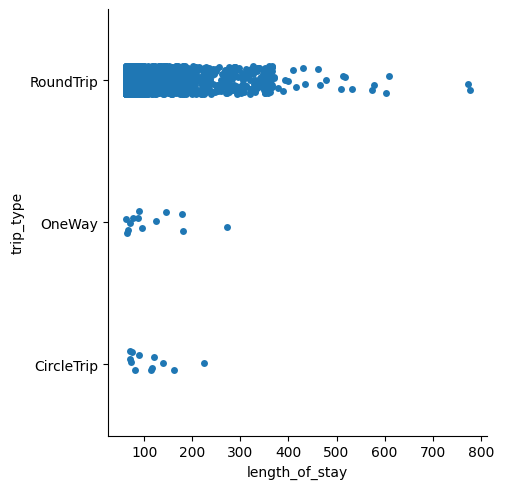

In [16]:
round_trip = df.query("stay_type == 'temporary_residence' or stay_type == 'residence'")
sns.catplot(round_trip,x='length_of_stay',y='trip_type')

In [17]:
stay_greater_than_year = df.query("length_of_stay >365").index
df = df.drop(index=stay_greater_than_year)
df_non_freq_encoded = df_non_freq_encoded.drop(index=stay_greater_than_year)
labels = labels.drop(index=stay_greater_than_year)

### Feature Encoding & Scaling

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 49977 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         49977 non-null  int64  
 1   sales_channel          49977 non-null  str    
 2   trip_type              49977 non-null  str    
 3   purchase_lead          49977 non-null  int64  
 4   length_of_stay         49977 non-null  int64  
 5   flight_hour            49977 non-null  int64  
 6   flight_day             49977 non-null  int64  
 7   wants_extra_baggage    49977 non-null  int64  
 8   wants_preferred_seat   49977 non-null  int64  
 9   wants_in_flight_meals  49977 non-null  int64  
 10  flight_duration        49977 non-null  float64
 11  stay_type              49977 non-null  str    
 12  passenger_kind         49977 non-null  str    
 13  travel_am_pm           49977 non-null  str    
 14  weekend                49977 non-null  int64  
 15  travelling_kind   

In [19]:
num_continuous_cols = ['num_passengers', 'purchase_lead', 'length_of_stay',
         'flight_duration', 'extra_services_count']
cyclic_cols = ['flight_hour','flight_day']
cat_cols = df.select_dtypes(exclude='number').columns.to_list()

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, SplineTransformer, FunctionTransformer, OneHotEncoder

def cyclic_name_handler(transformer,inputFeatures):
    return [f'{inputFeatures[0]}_sin',f'{inputFeatures[1]}_cosine']

# Helper function for sin and cosie encoding
def encode_hours(X):
    return np.column_stack([np.sin(2*np.pi*X/24), np.cos(2*np.pi*X/24)])

def encode_days(X):
    return np.column_stack([np.sin(2*np.pi*X/7), np.cos(2*np.pi*X/7)])

feature_engineering_pipeline = FunctionTransformer(engineer_features,validate=False)
feature_engineering_pipeline.set_output(transform='pandas')

preprocessor_cat = ColumnTransformer([
            ('continuous',StandardScaler(),num_continuous_cols),
            ('day_cyclic',FunctionTransformer(encode_days,feature_names_out=cyclic_name_handler),cyclic_cols[1]),
            ('hour_cyclic',FunctionTransformer(encode_hours,feature_names_out=cyclic_name_handler),cyclic_cols[0])
        ],remainder='passthrough')

preprocessor = ColumnTransformer([
            ('continuous',StandardScaler(),num_continuous_cols),
            ('day_cyclic',FunctionTransformer(encode_days,feature_names_out=cyclic_name_handler),cyclic_cols[1]),
            ('hour_cyclic',FunctionTransformer(encode_hours,feature_names_out=cyclic_name_handler),cyclic_cols[0]),
            ('categorical',OneHotEncoder(drop='first',sparse_output=False),cat_cols)
        ],remainder='passthrough')
preprocessor.set_output(transform="pandas")
preprocessor_cat.set_output(transform="pandas")




,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('day_cyclic', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

### Train Test Split:

In [21]:
from sklearn.model_selection import train_test_split
def get_train_test_split(df):
    return train_test_split(df,labels,test_size=0.2,random_state=42,stratify=labels) 

### Preprocessing

In [22]:
def get_features(df):
    return feature_engineering_pipeline.fit_transform(df)


def get_preprocessed_data(X_train,X_test,is_cat=False):
    pipeline = None
    if is_cat:
        pipeline = preprocessor_cat
    else:
        pipeline = preprocessor
    X_train_processed = pipeline.fit_transform(X_train)
    X_test_processed = pipeline.transform(X_test)
    return X_train_processed,X_test_processed

In [23]:
X_train,X_test,y_train,y_test = get_train_test_split(df)
X_train_processed, X_test_processed = get_preprocessed_data(X_train,X_test)

In [24]:
X_train_processed.shape

(39981, 34)

In [25]:
X_train_processed.info()

<class 'pandas.DataFrame'>
Index: 39981 entries, 49277 to 34969
Data columns (total 34 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   continuous__num_passengers                      39981 non-null  float64
 1   continuous__purchase_lead                       39981 non-null  float64
 2   continuous__length_of_stay                      39981 non-null  float64
 3   continuous__flight_duration                     39981 non-null  float64
 4   continuous__extra_services_count                39981 non-null  float64
 5   day_cyclic__0                                   39981 non-null  float64
 6   day_cyclic__1                                   39981 non-null  float64
 7   hour_cyclic__0                                  39981 non-null  float64
 8   hour_cyclic__1                                  39981 non-null  float64
 9   categorical__sales_channel_Mobile               399

## Training

In [26]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

#### Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegressionCV

log_reg = LogisticRegressionCV(
    cv=5,penalty='l2',
    solver='liblinear',
    scoring='roc_auc',
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1)
result = log_reg.fit(X_train_processed,y_train)

c:\Users\raaja\anaconda3\envs\ba_forage\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\raaja\anaconda3\envs\ba_forage\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\raaja\anaconda3\envs\ba_forage\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy

In [28]:
prediction = log_reg.predict(X_test_processed)

In [29]:
report = classification_report(y_test,prediction)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.59      0.72      8502
           1       0.23      0.69      0.34      1494

    accuracy                           0.60      9996
   macro avg       0.57      0.64      0.53      9996
weighted avg       0.81      0.60      0.66      9996



In [30]:


def draw_confusion_matrix(y_test,y_pred):
    # Generate the raw numbers
    cm = confusion_matrix(y_test, y_pred)

    # Plot it beautifully
    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Booking', 'Booking'])
    disp.plot(cmap='Blues', ax=ax)

    plt.title("Confusion Matrix: Flight Booking Predictions")
    plt.show()

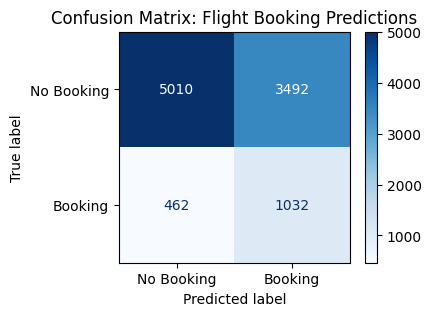

In [31]:
draw_confusion_matrix(y_test,prediction)

##### ROC Logistic

In [41]:
from sklearn.metrics import roc_auc_score

y_probs_logs = log_reg.predict_proba(X_test_processed)[:, 1]

auc_score = roc_auc_score(y_test, y_probs_logs)
print(f"AUC-ROC Score: {auc_score:.4f}")

AUC-ROC Score: 0.6904


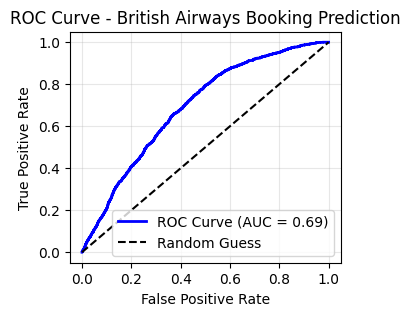

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs_logs)

plt.figure(figsize=(3.5, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - British Airways Booking Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#### Random Forest

In [32]:
rf = RandomForestClassifier(class_weight='balanced',random_state=42,n_jobs=-1)

rf_parameter_dist = {
    'n_estimators':[100,200,300,500,1000],
    'max_depth':[10,20,30,50,75],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2'],
    'bootstrap':[True,False]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfcv =  RandomizedSearchCV(
    rf,
    rf_parameter_dist,
    n_iter=20,
    random_state=42,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1
    )

In [33]:

rfcv.fit(X_train_processed,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versi

In [34]:
rf_pred = rfcv.best_estimator_.predict(X_test_processed)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      8502
           1       0.29      0.65      0.40      1494

    accuracy                           0.71      9996
   macro avg       0.61      0.69      0.60      9996
weighted avg       0.83      0.71      0.75      9996



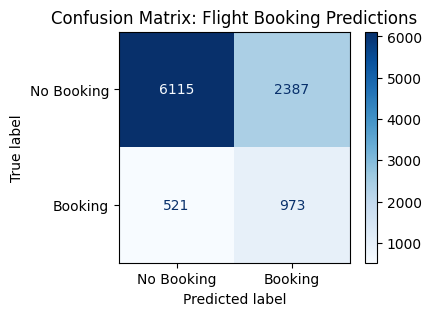

In [35]:
draw_confusion_matrix(y_test,rf_pred)

##### ROC AUC - RF

AUC-ROC Score: 0.7538


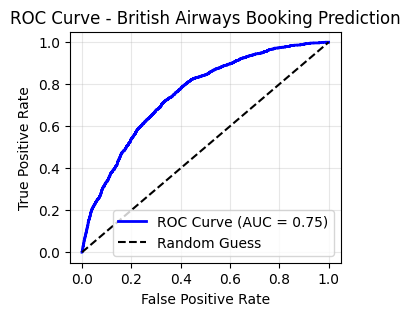

In [ ]:
y_probs_rf = rfcv.best_estimator_.predict_proba(X_test_processed)[:, 1]

auc_score = roc_auc_score(y_test, y_probs_rf)
print(f"AUC-ROC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_probs_rf)

plt.figure(figsize=(3.5, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - British Airways Booking Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#### XGBoost

In [36]:
from xgboost import XGBClassifier

xg_params = {
    'n_estimators':[100,300,500,1000],
    'learning_rate':[0.01, 0.05, 0.1, 0.2],
    'max_depth':[2,4,7,9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 3, 5.7, 7]
}

xgb = XGBClassifier(objective='binary:logistic',random_state=42,use_label_encoder=False)

xgb_cv = RandomizedSearchCV(
    xgb,
    param_distributions=xg_params,
    n_iter=20,
    scoring='f1',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)


In [37]:

xgb_cv.fit(X_train_processed,y_train)

c:\Users\raaja\anaconda3\envs\ba_forage\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:49:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 4, ...], 'n_estimators': [100, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [38]:
xgb_pred = xgb_cv.best_estimator_.predict(X_test_processed)
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.92      0.80      0.86      8502
           1       0.34      0.58      0.43      1494

    accuracy                           0.77      9996
   macro avg       0.63      0.69      0.64      9996
weighted avg       0.83      0.77      0.79      9996



##### ROC AUC - XGBoost

AUC-ROC Score: 0.7890


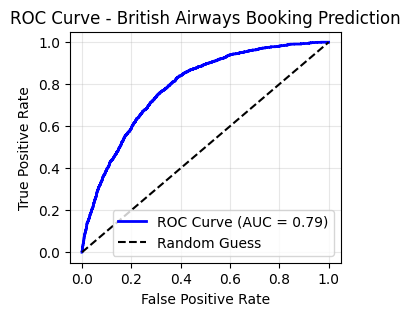

In [ ]:
y_probs_xgb = xgb_cv.best_estimator_.predict_proba(X_test_processed)[:, 1]

auc_score = roc_auc_score(y_test, y_probs_xgb)
print(f"AUC-ROC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb)

plt.figure(figsize=(3.5, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - British Airways Booking Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#### Light GBM

In [39]:
from lightgbm import LGBMClassifier

lgbm_params = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1,0.2],
    'num_leaves': [31, 64, 128], # Main parameter for LGBM
    'max_depth': [-1, 2, 5, 10],    # -1 means no limit
    'subsample': [0.6, 0.8, 0.9],
    'scale_pos_weight': [1, 3, 5.7, 7]
}

lgbm = LGBMClassifier(random_state=42, importance_type='gain')

lgbm_cv = RandomizedSearchCV(
    lgbm,
    param_distributions=lgbm_params,
    n_iter=20,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

lgbm_cv.fit(X_train_processed, y_train)

[LightGBM] [Info] Number of positive: 5978, number of negative: 34003
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 810
[LightGBM] [Info] Number of data points in the train set: 39981, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.149521 -> initscore=-1.738363
[LightGBM] [Info] Start training from score -1.738363


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 2, ...], 'n_estimators': [100, 300, ...], 'num_leaves': [31, 64, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... ver

In [40]:
lgbm_pred = lgbm_cv.best_estimator_.predict(X_test_processed)
print(classification_report(y_test,lgbm_pred))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83      8502
           1       0.32      0.67      0.43      1494

    accuracy                           0.74      9996
   macro avg       0.62      0.71      0.63      9996
weighted avg       0.84      0.74      0.77      9996



##### ROC AUC - LightGBM

AUC-ROC Score: 0.7863


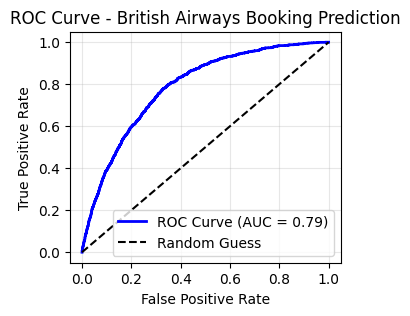

In [46]:
y_probs_lgb = lgbm_cv.best_estimator_.predict_proba(X_test_processed)[:, 1]

auc_score = roc_auc_score(y_test, y_probs_lgb)
print(f"AUC-ROC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_probs_lgb)

plt.figure(figsize=(3.5, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - British Airways Booking Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#### CatBoost

In [47]:

X_train_cat,X_test_cat,y_train_cat,y_test_cat = get_train_test_split(df_non_freq_encoded)
X_train_processed_cat,X_test_processed_cat = get_preprocessed_data(X_train_cat,X_test_cat,is_cat=True)

In [48]:
X_train_processed_cat.shape

(39981, 25)

In [49]:
cat_features_model = X_train_processed_cat.select_dtypes(include=['str','object']).columns.to_list()
print(cat_features_model)
X_train_processed_cat.info()

['remainder__sales_channel', 'remainder__trip_type', 'remainder__booking_origin', 'remainder__stay_type', 'remainder__passenger_kind', 'remainder__travel_am_pm', 'remainder__travelling_kind', 'remainder__departure', 'remainder__arrival', 'remainder__lead_category', 'remainder__flight_period', 'remainder__booking_behavior']
<class 'pandas.DataFrame'>
Index: 39981 entries, 49277 to 34969
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   continuous__num_passengers        39981 non-null  float64
 1   continuous__purchase_lead         39981 non-null  float64
 2   continuous__length_of_stay        39981 non-null  float64
 3   continuous__flight_duration       39981 non-null  float64
 4   continuous__extra_services_count  39981 non-null  float64
 5   day_cyclic__0                     39981 non-null  float64
 6   day_cyclic__1                     39981 non-null  float64
 7   hour_c

In [50]:
from catboost import CatBoostClassifier


cat_params = {
    'iterations': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7],
    'auto_class_weights': ['Balanced', 'SqrtBalanced']
}

cat = CatBoostClassifier(verbose=0, random_state=42,thread_count=-1)

cat_cv = RandomizedSearchCV(
    cat,
    param_distributions=cat_params,
    n_iter=15,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)
# If you use raw data, specify cat_features=[index_of_categorical_columns]

cat_cv.fit(X_train_processed_cat, y_train_cat,cat_features=cat_features_model,early_stopping_rounds=50)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...42, verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'auto_class_weights': ['Balanced', 'SqrtBalanced'], 'depth': [4, 6, ...], 'iterations': [500, 1000], 'l2_leaf_reg': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [51]:
cat_pred = cat_cv.best_estimator_.predict(X_test_processed_cat)
print(classification_report(y_test_cat,cat_pred))

              precision    recall  f1-score   support

           0       0.94      0.72      0.81      8502
           1       0.32      0.74      0.44      1494

    accuracy                           0.72      9996
   macro avg       0.63      0.73      0.63      9996
weighted avg       0.85      0.72      0.76      9996



##### ROC AUC - CatBoost

AUC-ROC Score: 0.7975


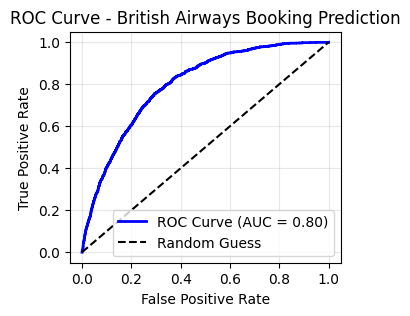

In [52]:
y_probs_cat = cat_cv.best_estimator_.predict_proba(X_test_processed_cat)[:, 1]

auc_score = roc_auc_score(y_test, y_probs_cat)
print(f"AUC-ROC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_probs_cat)

plt.figure(figsize=(3.5, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - British Airways Booking Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#### Training with SMOTE

In [48]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df_smote = pd.read_csv('../data/customer_booking.csv',encoding='ISO-8859-1')
labels = df_smote['booking_complete']
df_smote = df_smote.drop(columns=['booking_complete'])
df_smote = df_smote.drop(index=stay_greater_than_year)
labels = labels.drop(index=stay_greater_than_year)

df_smote = engineer_features(df_smote)
freq_cols = ['departure','arrival','booking_origin']
for col in freq_cols:
    freq = df_smote[col].value_counts(normalize=True)
    df_smote[col+'_freq'] = df_smote[col].map(freq)
df_smote.drop(columns=freq_cols,inplace=True)

X_train_smote,X_test_smote,y_train_smote,y_test_smote = train_test_split(df_smote,labels,test_size=0.2,random_state=42,stratify=labels) 

X_train_smote_processed = preprocessor.fit_transform(X_train_smote,labels) 

all_steps =  [
        ('smote', SMOTE(random_state=42)),
        ('xgb', XGBClassifier(objective='binary:logistic', random_state=42, use_label_encoder=False))
    ]

imb_pipeline = ImbPipeline(all_steps)

xg_smote_params = {
            'xgb__n_estimators':[100,300,500,1000],
            'xgb__learning_rate':[0.01, 0.05, 0.1, 0.2],
            'xgb__max_depth':[2,4,7,9],
            'xgb__subsample': [0.6, 0.8, 1.0],
            'xgb__colsample_bytree': [0.6, 0.8, 1.0],
            'smote__k_neighbors':[3,5]
            }
        
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


xgb_smote_cv = RandomizedSearchCV(
            imb_pipeline,
            param_distributions=xg_smote_params,
            n_iter=20,
            scoring='f1',
            cv=cv_strategy,
            random_state=42,
            n_jobs=-1,
            error_score='raise'
        )



In [49]:
xgb_smote_cv.fit(X_train_smote_processed,y_train_smote)

c:\Users\raaja\anaconda3\envs\ba_forage\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:51:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'smote__k_neighbors': [3, 5], 'xgb__colsample_bytree': [0.6, 0.8, ...], 'xgb__learning_rate': [0.01, 0.05, ...], 'xgb__max_depth': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

In [52]:
X_test_smote_processed = preprocessor.transform(X_test_smote) 
xg_smote_pred = xgb_smote_cv.best_estimator_.predict(X_test_smote_processed)
print(classification_report(y_test_smote,xg_smote_pred))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86      8502
           1       0.31      0.46      0.37      1494

    accuracy                           0.77      9996
   macro avg       0.61      0.64      0.62      9996
weighted avg       0.81      0.77      0.79      9996



## Feature Importance

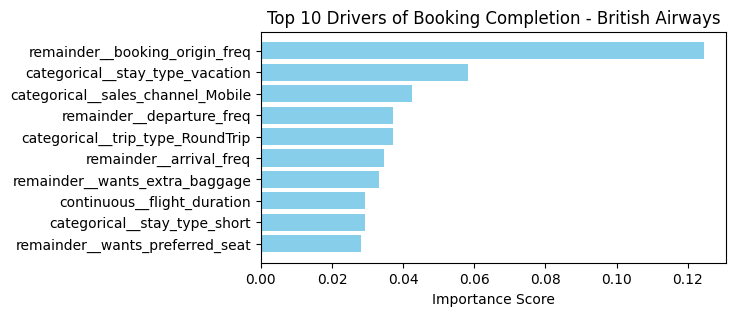

In [ ]:
cat_importances = cat_cv.best_estimator_.get_feature_importance()

feature_importance_df = pd.DataFrame({'feature':X_train_processed.columns,'importance':cat_importances})
feature_importance_df = feature_importance_df.sort_values(by='importance',ascending=False)

plt.figure(figsize=(6, 3))
plt.barh(feature_importance_df['feature'][:10], feature_importance_df['importance'][:10], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Drivers of Booking Completion - British Airways')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance


# Calculate permutation importance on the TEST set
result = permutation_importance(
    cat_cv.best_estimator_, X_test_processed, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

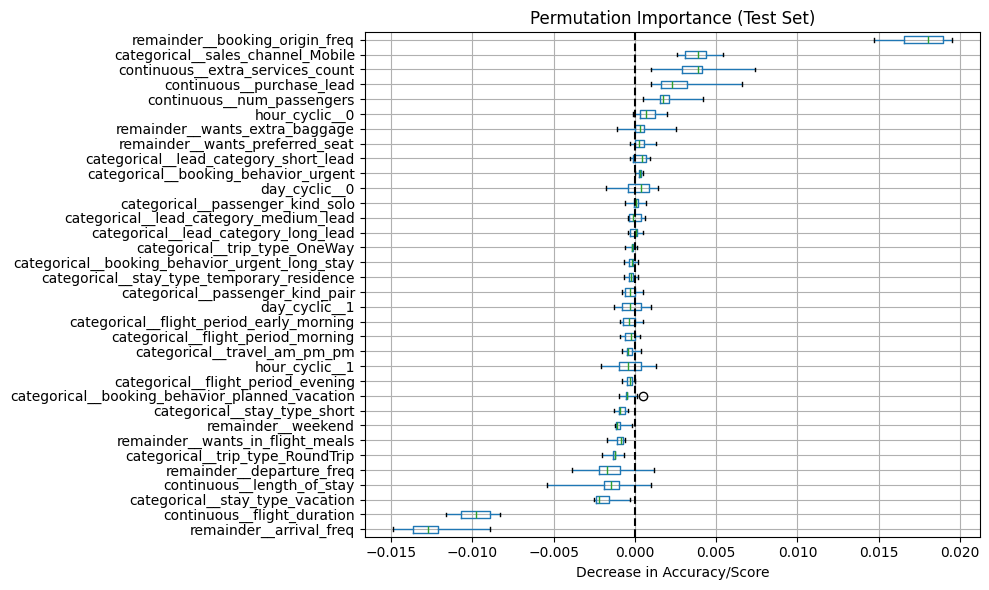

In [73]:
perm_sorted_idx = result.importances_mean.argsort()
perm_df = pd.DataFrame(
    result.importances[perm_sorted_idx].T,
    columns=X_test_processed.columns[perm_sorted_idx],
)


plt.figure(figsize=(10, 6))
perm_df.boxplot(vert=False, whis=10)
plt.title("Permutation Importance (Test Set)")
plt.axvline(x=0, color="k", linestyle="--")
plt.xlabel("Decrease in Accuracy/Score")
plt.tight_layout()
plt.show()

The model achieved an AUC-ROC of 0.80, indicating a strong ability to distinguish between customers who will and will not complete a booking. Permutation Importance reveals that Booking Origin is the primary driver of predictions, followed by the Sales Channel, Purchase Lead time, extra services taken, hours and no of passengers. Whereas features like Flight Duration contributed more noise than signal.